In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression  
from sklearn.metrics import mean_absolute_error, r2_score  
from sklearn.model_selection import train_test_split

C:\Users\manth\AppData\Roaming\Python\Python311\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
df = pd.read_csv('Diwali Sales Data.csv', encoding = 'unicode_escape')
#encoding is used to handle errors.

In [3]:
df

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11246,1000695,Manning,P00296942,M,18-25,19,1,Maharashtra,Western,Chemical,Office,4,370.0,NaN,NaN
11247,1004089,Reichenbach,P00171342,M,26-35,33,0,Haryana,Northern,Healthcare,Veterinary,3,367.0,NaN,NaN
11248,1001209,Oshin,P00201342,F,36-45,40,0,Madhya Pradesh,Central,Textile,Office,4,213.0,NaN,NaN
11249,1004023,Noonan,P00059442,M,36-45,37,0,Karnataka,Southern,Agriculture,Office,3,206.0,NaN,NaN


## Features Of Dataset:

1.User_ID: A unique identifier assigned to each customer.

2.Cust_name: The name of the customer.

3.Product_ID: A unique identifier for the purchased product.

4.Gender: The gender of the customer (M = Male, F = Female).

5.Age Group: The age range of the customer (e.g., 26-35, 18-25).

6.Age: The exact age of the customer.

7.Marital_Status: Indicates if the customer is married (1) or single (0).

8.State: The state where the customer resides.

9.Zone: The geographical zone of the customer (e.g., Western, Southern).

10.Occupation: The customer's occupation (e.g., Healthcare, Govt, Construction).

11.Product_Category: The category of the purchased product (e.g., Auto, Office, Veterinary).

12.Orders: The number of times the customer has placed an order.

13.Amount: The total purchase amount spent by the customer.

In [4]:
df.shape

(11251, 15)

In [5]:
df.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Occupation        11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), object(8)
memory usage: 1.3+ MB


In [7]:
d = (df.duplicated())

In [8]:
df.drop(['Status','unnamed1'], axis=1, inplace=True)
#inplace used to save changes in dataframes.
# axis=1 used to drop these columns by their names from the DataFrame.
#If you used axis=0 or default, it would attempt to drop rows instead of columns.

In [9]:
pd.isnull(df).sum()

User_ID              0
Cust_name            0
Product_ID           0
Gender               0
Age Group            0
Age                  0
Marital_Status       0
State                0
Zone                 0
Occupation           0
Product_Category     0
Orders               0
Amount              12
dtype: int64

In [10]:
df.dropna(inplace=True)
#inplace used to save changes after drop.

In [11]:
df.isnull().sum()

User_ID             0
Cust_name           0
Product_ID          0
Gender              0
Age Group           0
Age                 0
Marital_Status      0
State               0
Zone                0
Occupation          0
Product_Category    0
Orders              0
Amount              0
dtype: int64

In [12]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='object')

In [13]:
df.describe()
#Here We don't requird User_ID & Marital_Status for describe.

,User_ID,Age,Marital_Status,Orders,Amount
count,1.123900e+04,11239.000000,11239.000000,11239.000000,11239.000000
mean,1.003004e+06,35.410357,0.420055,2.489634,9453.610858
std,1.716039e+03,12.753866,0.493589,1.114967,5222.355869
min,1.000001e+06,12.000000,0.000000,1.000000,188.000000
25%,1.001492e+06,27.000000,0.000000,2.000000,5443.000000
50%,1.003064e+06,33.000000,0.000000,2.000000,8109.000000
75%,1.004426e+06,43.000000,1.000000,3.000000,12675.000000
max,1.006040e+06,92.000000,1.000000,4.000000,23952.000000


In [14]:
df[['Age','Orders','Amount']].describe ()

,Age,Orders,Amount
count,11239.000000,11239.000000,11239.000000
mean,35.410357,2.489634,9453.610858
std,12.753866,1.114967,5222.355869
min,12.000000,1.000000,188.000000
25%,27.000000,2.000000,5443.000000
50%,33.000000,2.000000,8109.000000
75%,43.000000,3.000000,12675.000000
max,92.000000,4.000000,23952.000000


# Exploratory Data Analysis

## Gender 

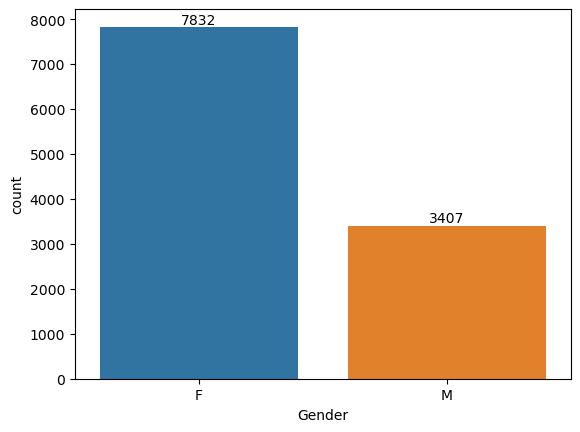

In [15]:
ax = sns.countplot(x='Gender', data=df)


#Used to display values of count
for bars in ax.containers:
    ax.bar_label(bars)

<Axes: xlabel='Gender', ylabel='Amount'>

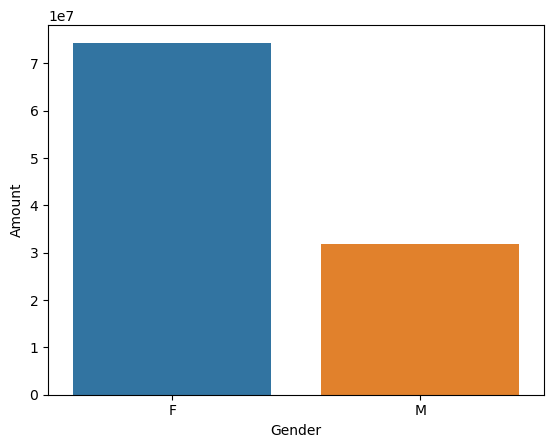

In [16]:
GenderVsAmount = df.groupby(['Gender'],as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)

sns.barplot(x='Gender', y='Amount', data=GenderVsAmount)
#'as_index=False' ensures that the Gender column remains a regular column in the 
# resulting DataFrame, rather than becoming the index.

From the above graph we can see that most of the buyers are females and even the purchasing amount of females is also greater than men

## Age

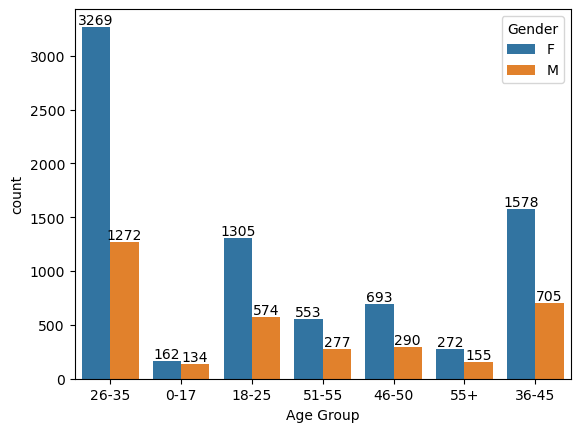

In [17]:
ax = sns.countplot(x='Age Group', hue='Gender', data=df)
#hue allows you to visually compare the counts of different genders within each age group and making the plot more informative.

for bars in ax.containers:
    ax.bar_label(bars)

<Axes: xlabel='Age Group', ylabel='Amount'>

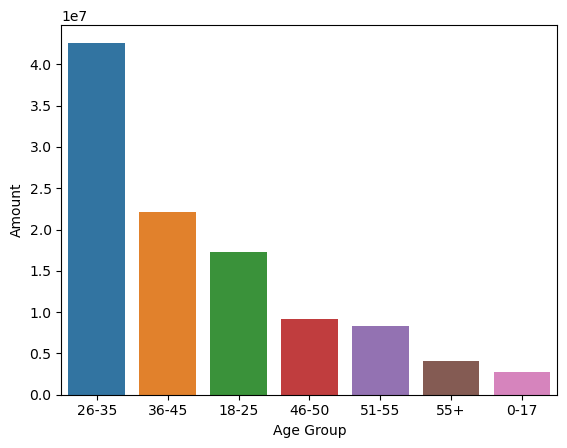

In [18]:
sales_age = df.groupby(['Age Group'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)

sns.barplot(data = sales_age, x= 'Age Group', y='Amount')

From above two graphs we can see that the highest customers comes from Age Group of 26-35 females

<Axes: xlabel='State', ylabel='Orders'>

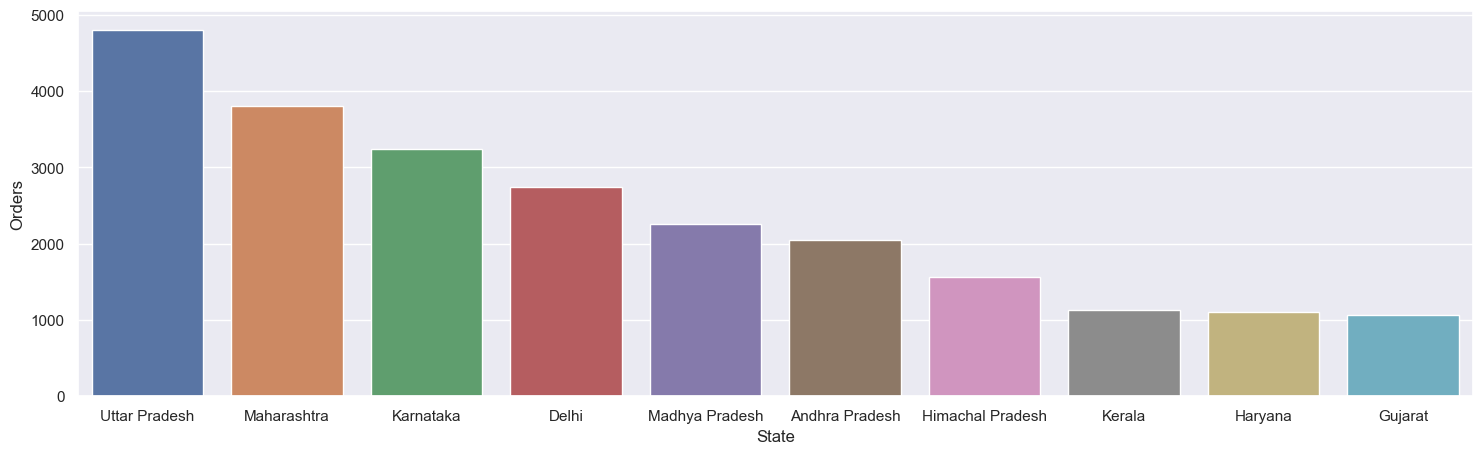

In [19]:
sales_state = df.groupby(['State'], as_index=False)['Orders'].sum().sort_values(by='Orders', ascending=False).head(10)

sns.set(rc={'figure.figsize':(18,5)})
sns.barplot(data= sales_state, x='State', y='Orders')  

<Axes: xlabel='State', ylabel='Amount'>

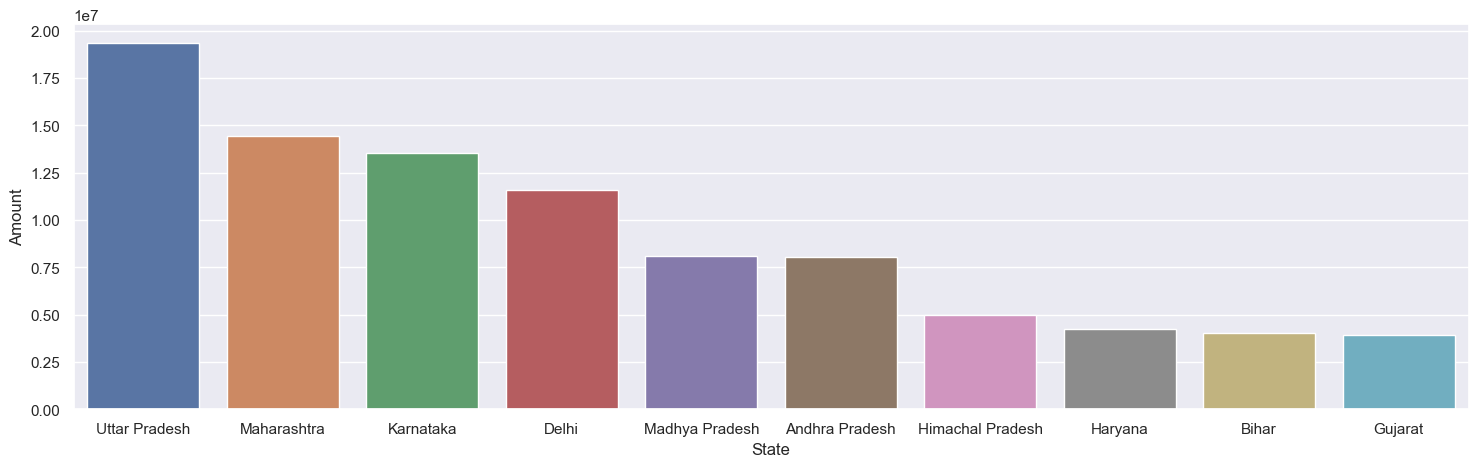

In [20]:
sales_state = df.groupby(['State'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False).head(10)

sns.barplot(data=sales_state ,x='State', y='Amount')

From above graphs we can see that highest orders & total sales are from Uttar Pradesh, Maharastra, Karnataka.

## Marital Status

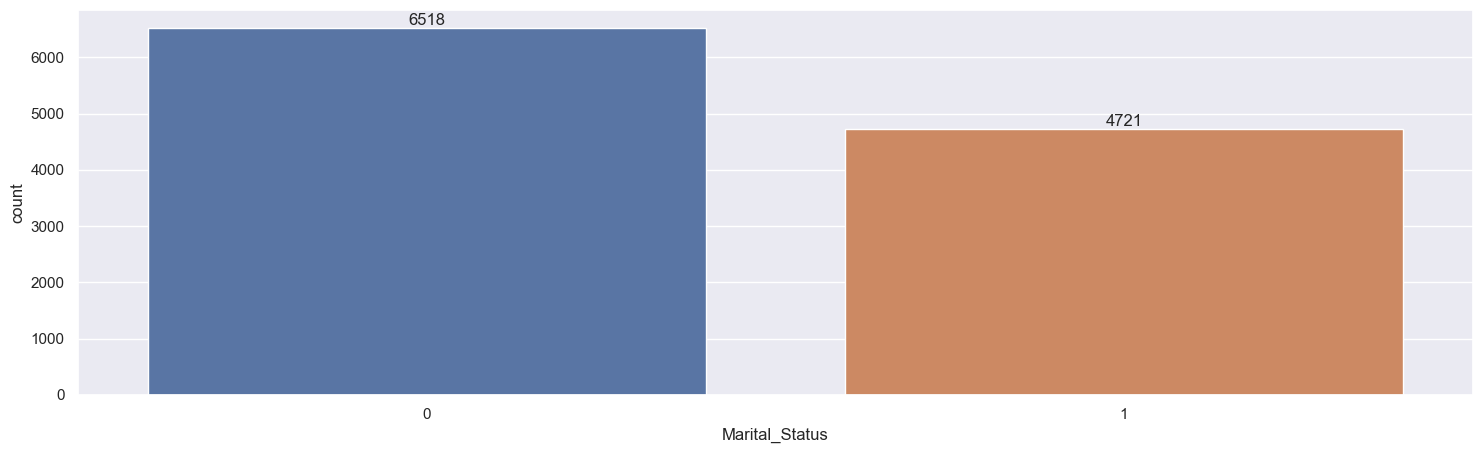

In [21]:
ax = sns.countplot(data=df, x='Marital_Status')

sns.set(rc={'figure.figsize':(5,5)})
for bars in ax.containers:
    ax.bar_label(bars)

<Axes: xlabel='Marital_Status', ylabel='Amount'>

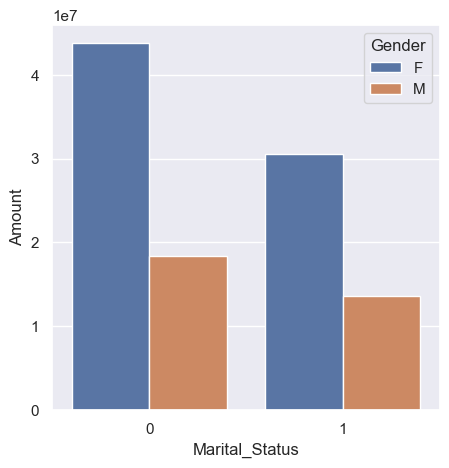

In [22]:
GenderVSMarital= df.groupby(['Marital_Status', 'Gender'], as_index=False)['Amount'].sum()

sns.barplot(data=GenderVSMarital, x='Marital_Status', y='Amount', hue='Gender' )

From above graphs we can see that most of the buyers are married females and their amount of order is also high.

## Occupation

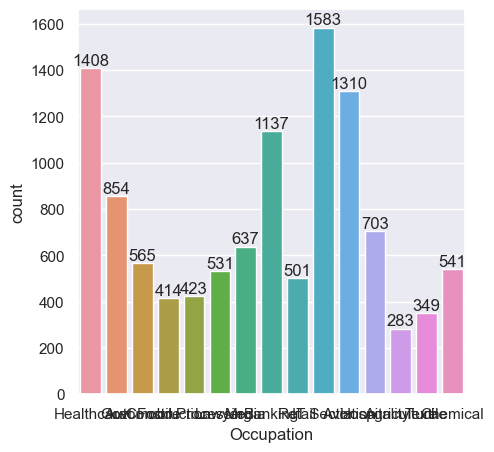

In [23]:
ax = sns.countplot(data=df, x='Occupation')

sns.set(rc={'figure.figsize':(22,5)})
for bars in ax.containers:
    ax.bar_label(bars)

<Axes: xlabel='Occupation', ylabel='Amount'>

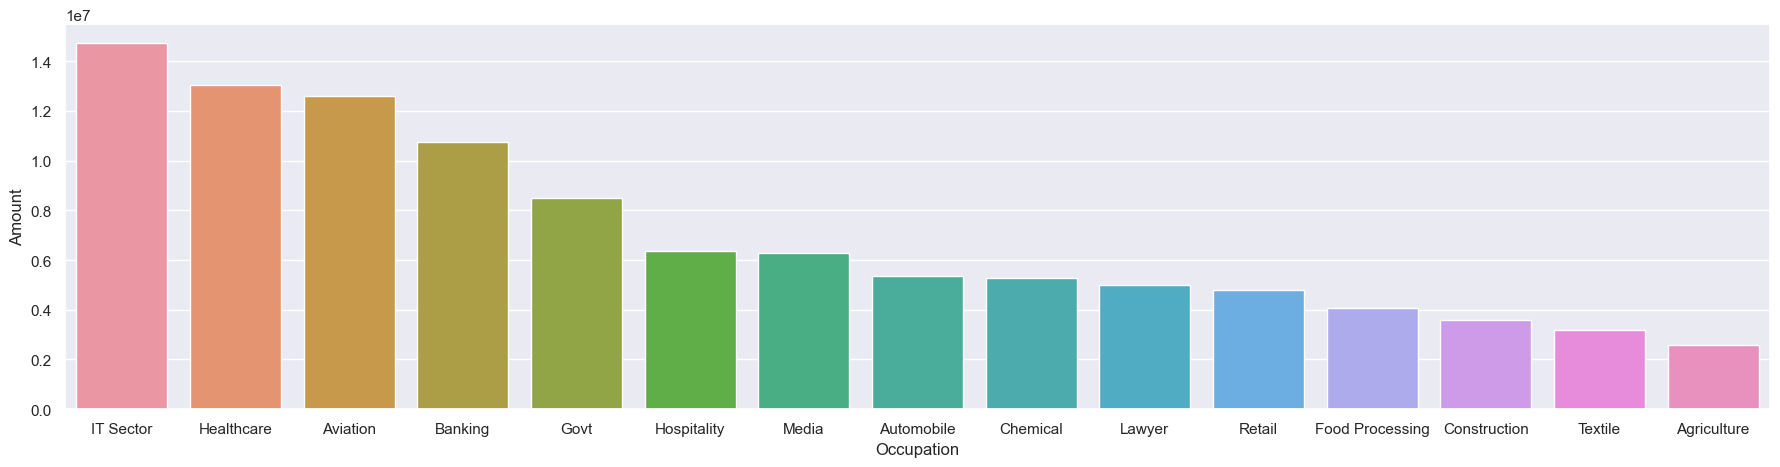

In [24]:
sales_occupation = df.groupby(['Occupation'], as_index=False)['Amount'].sum().sort_values(by= 'Amount', ascending=False)

sns.barplot(data= sales_occupation, x='Occupation', y='Amount')

From above graphs we can see that most of buyers from IT sector, Healthcare & Aviation sector.

## Product Category

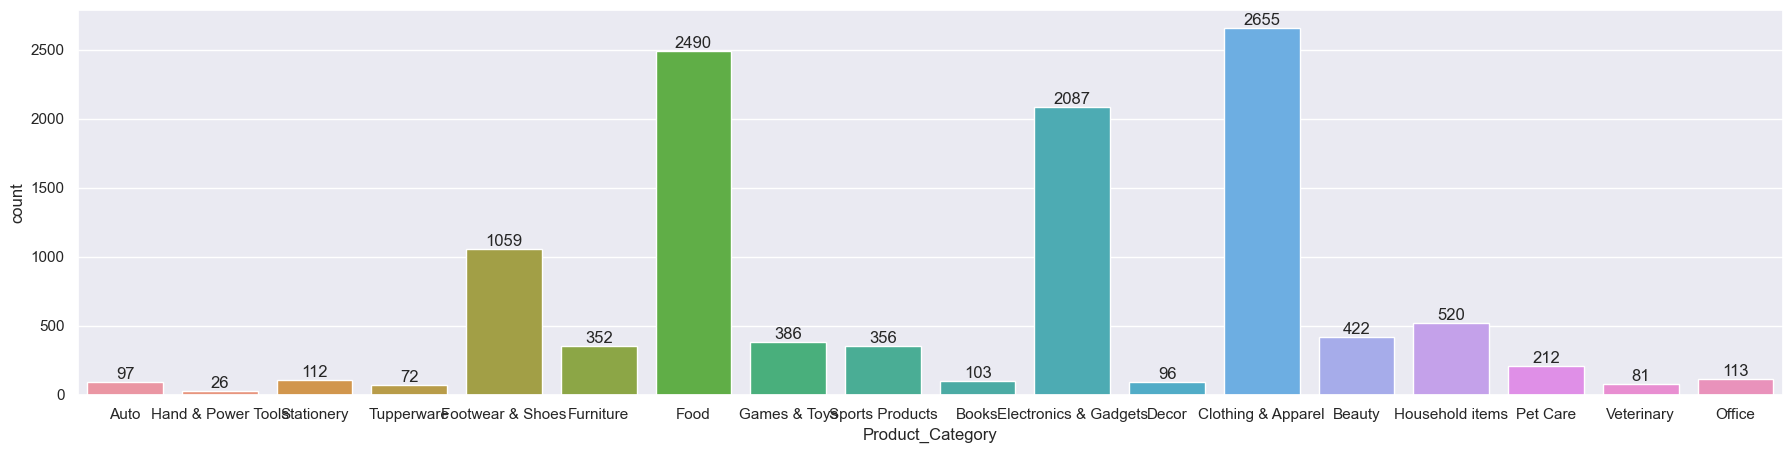

In [25]:
ax= sns.countplot(data=df, x='Product_Category')

sns.set(rc={'figure.figsize':(25,8)})
for bars in ax.containers:
    ax.bar_label(bars)

<Axes: xlabel='Product_Category', ylabel='Amount'>

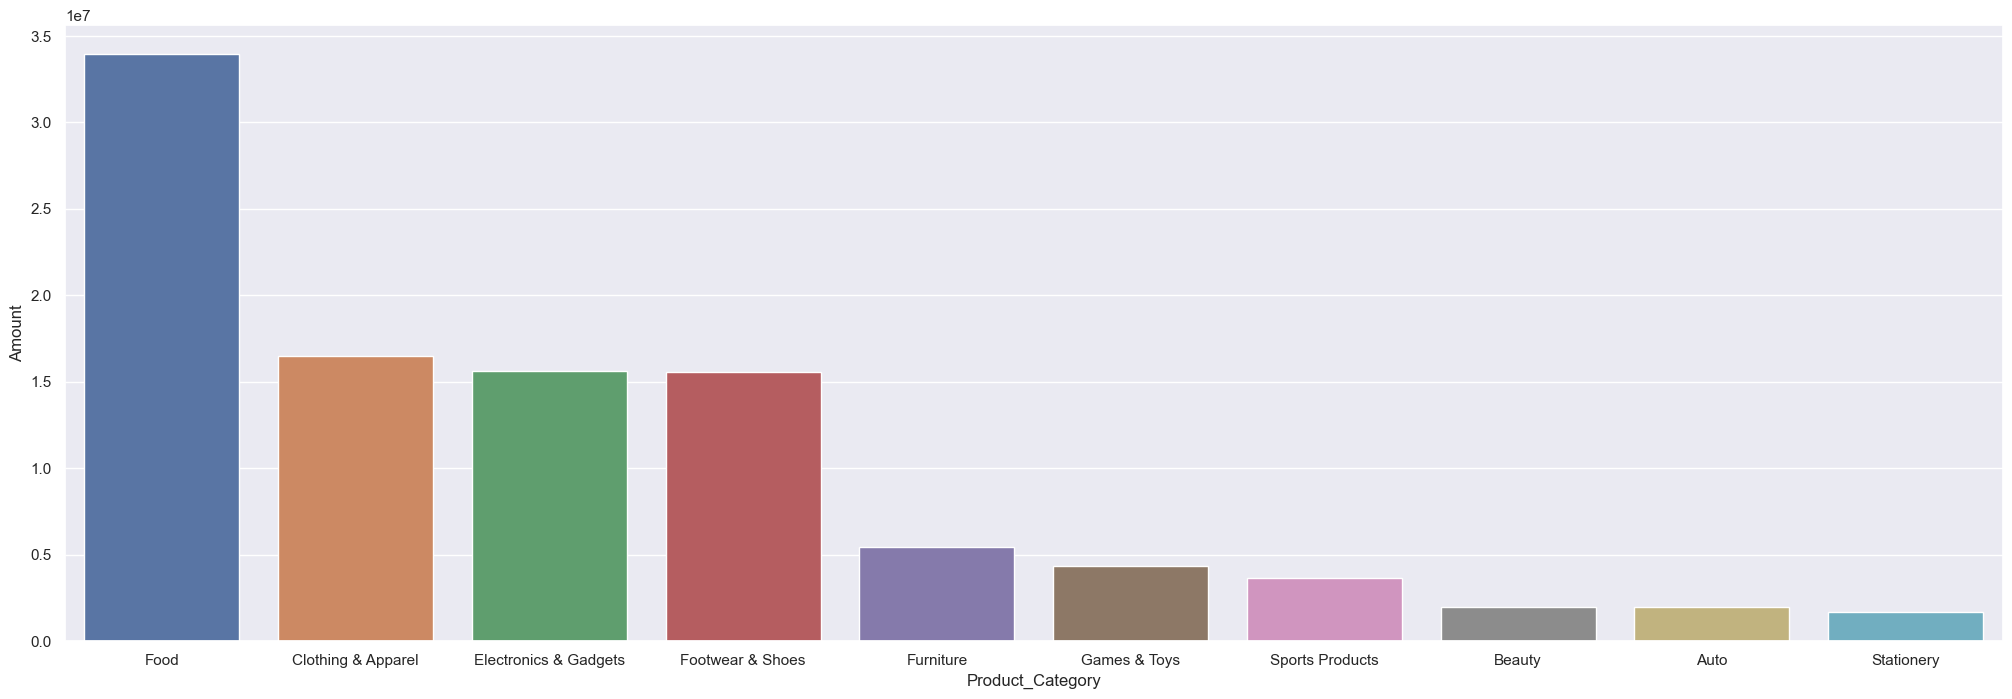

In [26]:
sales_product = df.groupby(['Product_Category'], as_index=False)['Amount'].sum().sort_values(by= 'Amount', ascending=False).head(10)

sns.set(rc={'figure.figsize':(25,8)})
sns.barplot(data=sales_product, x='Product_Category', y='Amount')

<Axes: xlabel='Product_ID', ylabel='Orders'>

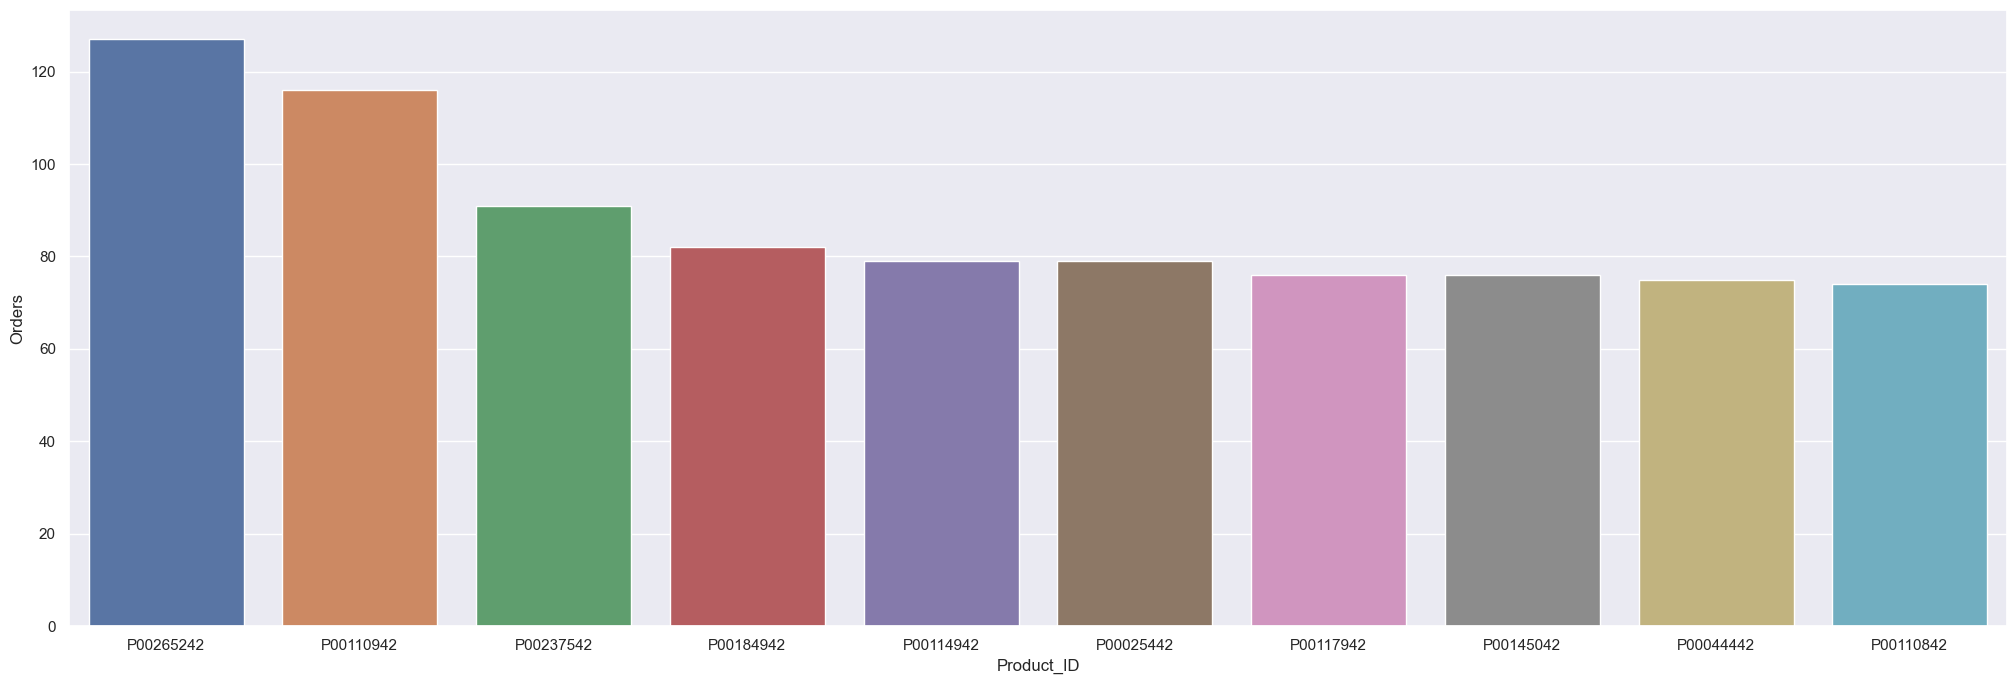

In [27]:
sales_productID = df.groupby(['Product_ID'], as_index=False)['Orders'].sum().sort_values(by='Orders', ascending=False).head(10)

sns.barplot(data=sales_productID, x='Product_ID', y='Orders')

## Important Insights 

*Married women age group 26-35 yrs from UP,  Maharastra and Karnataka working in IT, Healthcare and Aviation are more likely to buy products from Food, Clothing and Electronics category*

# Label Encoding

In [28]:
encoder = LabelEncoder()

In [29]:
df['Cust_name'] = encoder.fit_transform(df['Cust_name'])
df['Product_ID'] = encoder.fit_transform(df['Product_ID'])
df['Gender'] = encoder.fit_transform(df['Gender'])
df['State'] = encoder.fit_transform(df['State'])
df['Zone'] = encoder.fit_transform(df['Zone'])
df['Age Group'] = encoder.fit_transform(df['Age Group'])
df['Occupation'] = encoder.fit_transform(df['Occupation'])
df['Product_Category'] = encoder.fit_transform(df['Product_Category'])

In [30]:
df.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount
0,1002903,991,774,0,2,28,0,10,4,8,0,1,23952.0
1,1000732,596,644,0,2,35,1,0,3,7,0,3,23934.0
2,1001990,150,714,0,2,35,1,14,0,1,0,3,23924.0
3,1001425,1102,1507,1,0,16,0,7,3,5,0,2,23912.0
4,1000588,574,387,1,2,28,1,3,4,6,0,2,23877.0


# Machine Learning

In [31]:
#splitting features and Tareget Variable 
X = df.drop(columns='Amount', axis=1)
Y = df['Amount']

In [32]:
print(X)

       User_ID  Cust_name  Product_ID  Gender  Age Group  Age  Marital_Status  \
0      1002903        991         774       0          2   28               0   
1      1000732        596         644       0          2   35               1   
2      1001990        150         714       0          2   35               1   
3      1001425       1102        1507       1          0   16               0   
4      1000588        574         387       1          2   28               1   
...        ...        ...         ...     ...        ...  ...             ...   
11246  1000695        698        1888       1          1   19               1   
11247  1004089        938        1039       1          2   33               0   
11248  1001209        844        1263       0          3   40               0   
11249  1004023        817         396       1          3   37               0   
11250  1002744        186        1786       0          1   19               0   

       State  Zone  Occupat

In [33]:
print(Y)

0        23952.0
1        23934.0
2        23924.0
3        23912.0
4        23877.0
          ...   
11246      370.0
11247      367.0
11248      213.0
11249      206.0
11250      188.0
Name: Amount, Length: 11239, dtype: float64


In [34]:
#Splitting data into training data and testing data
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.5, random_state=2)
#test_size defines the percentage of data allocated to the test set.
#random_state ensures the consistent results for debugging and model tunning 

In [35]:
print(X.shape, X_train.shape, X_test.shape)

(11239, 12) (5619, 12) (5620, 12)


In [36]:
model = LinearRegression()  

In [37]:
model.fit(X_train, Y_train)  

LinearRegression()

# Evaluation

In [45]:
#Prediction for training data
Y_pred = model.predict(X_test) 
Y_pred

array([ 8840.10375848,  9012.81175367,  9123.59650035, ...,
        8858.60498629, 10141.09952282,  9319.28533086])

In [46]:
mae = mean_absolute_error(Y_test, Y_pred)  
mae

4217.8175065510395

In [43]:
#R square value
r2 = r2_score(Y_test, Y_pred)
r2

0.010002185970153676

In [41]:
print(f"Mean Absolute Error: {mae}") 

Mean Absolute Error: 4217.8175065510395


In [42]:
print(f"R-Squared Score: {r2}") 

R-Squared Score: 0.010002185970153676
